# 02 — Uczenie reprezentacji: InfoNCE vs Barlow Twins vs Transformer

Porównujemy trzy **samonadzorowane** (self-supervised) sposoby uczenia reprezentacji
sekwencji stanu gry Catan, oceniane wspólnym protokołem **linear-probe** na zadaniu
5-klasowej klasyfikacji typu **ukrytej karty development**. Wspólny backbone to
**Transformer** (`src/models.py`) — różni się tylko obiektyw pretreningu.

| Metoda | Typ | Co wymusza na reprezentacji | Plik |
|---|---|---|---|
| **InfoNCE / CPC** | kontrastywne, czasowe | przewidywanie przyszłych kroków z przeszłości → **dynamika** | `src/ssl_infonce.py` |
| **Barlow Twins** | nie-kontrastywne | niezmienniczość wzgl. augmentacji + dekorelacja → **inwariancja** | `src/ssl_barlow.py` |
| **Transformer MAE** | masked modeling | rekonstrukcja zamaskowanych kroków → **struktura** | `src/ssl_mae.py` |

Punkty odniesienia: **raw** (regresja logistyczna bez enkodera), **random** (enkoder
nieuczony), **supervised** (enkoder uczony z etykietami — górna granica).

**Co pokazujemy w tym notebooku:**
1. krzywe strat pretreningu,
2. główne porównanie macro-F1 (seen vs `unseen_mcts`) + luka generalizacji,
3. F1 per klasa,
4. **t-SNE** przestrzeni reprezentacji,
5. jakość reprezentacji **bez etykiet** (kNN-probe + silhouette),
6. **macierze pomyłek** per metoda,
7. **krzywa efektywności etykiet** (probe na 1–100% etykiet) — kluczowy argument za SSL.

> Wymaga wcześniejszego: `.venv-ml/Scripts/python -m src.train_all`
> (tworzy `results/metrics.json`, `losses.json`, `encoder_*.pt`).

In [1]:
import sys, json, os, warnings
sys.path.insert(0, "..")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.constrained_layout.use": True,
    "axes.titleweight": "semibold",
    "axes.titlepad": 10,
})

RES = "../results"
LABELS = ["KNIGHT", "VICTORY_POINT", "ROAD_BUILDING", "MONOPOLY", "YEAR_OF_PLENTY"]
SHORT = {"KNIGHT": "Rycerz", "VICTORY_POINT": "Punkt zw.", "ROAD_BUILDING": "Budowa dróg",
         "MONOPOLY": "Monopol", "YEAR_OF_PLENTY": "Rok obfit."}
LAB_PL = [SHORT[l] for l in LABELS]
NICE = {"raw": "Raw (baseline)", "random": "Random enc.", "infonce": "InfoNCE/CPC",
        "barlow": "Barlow Twins", "mae": "Transformer MAE", "supervised": "Supervised (UB)"}
MCOL = {"raw": "#9e9e9e", "random": "#bdbdbd", "infonce": "#4c72b0",
        "barlow": "#55a868", "mae": "#c44e52", "supervised": "#8172b3"}

metrics = json.load(open(f"{RES}/metrics.json", encoding="utf8"))["metrics"]
losses = json.load(open(f"{RES}/losses.json", encoding="utf8"))
ORDER = [m for m in ["raw", "random", "infonce", "barlow", "mae", "supervised"] if m in metrics]
print("metody w metrics.json:", ORDER)

metody w metrics.json: ['raw', 'random', 'infonce', 'barlow', 'mae', 'supervised']


## 1. Krzywe strat pretreningu

Sanity-check zbieżności każdego obiektywu. Skale strat są **nieporównywalne** między
metodami (inne funkcje celu) — liczy się trend malejący.

findfont: Failed to find font weight semibold, now using 700.


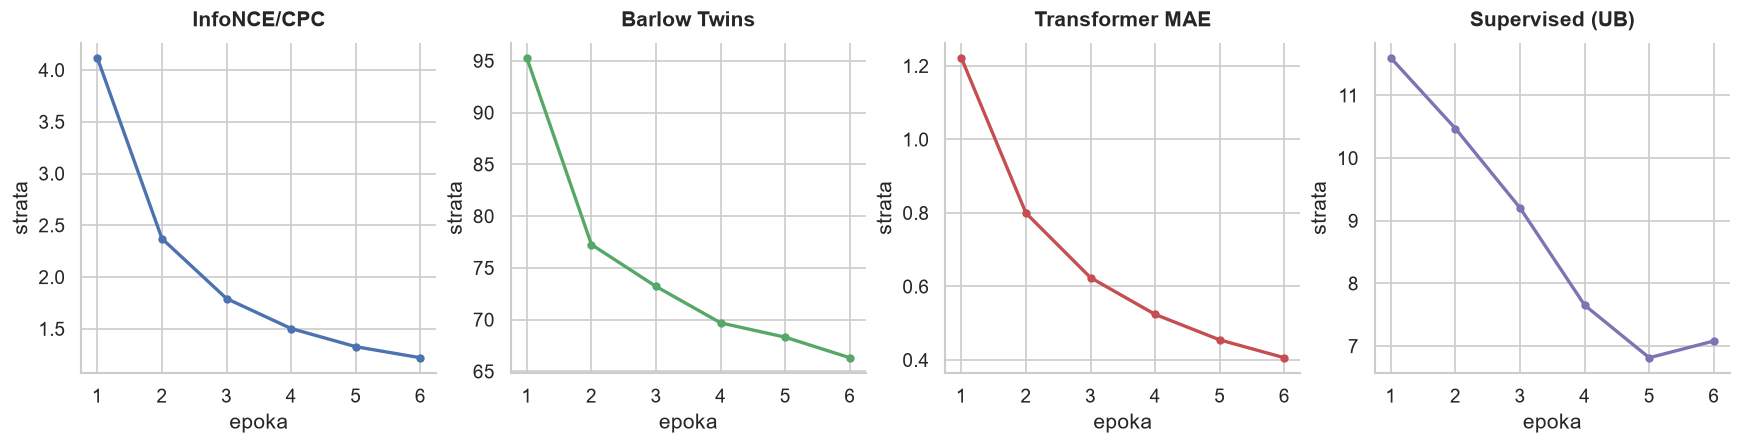

In [2]:
trainable = [m for m in ["infonce", "barlow", "mae", "supervised"] if losses.get(m)]
fig, axes = plt.subplots(1, len(trainable), figsize=(3.6 * len(trainable), 3.6), squeeze=False)
for ax, m in zip(axes[0], trainable):
    ax.plot(range(1, len(losses[m]) + 1), losses[m], marker="o", ms=4, color=MCOL[m], lw=2)
    ax.set_title(NICE[m]); ax.set_xlabel("epoka"); ax.set_ylabel("strata")
sns.despine(fig)
plt.show()

## 2. Główne porównanie — macro-F1 (seen vs unseen)

Najważniejszy wykres. Czytamy: czy metody SSL biją **random** (czy pretrening pomaga),
jak daleko są od **supervised** (górnej granicy) i jak duży jest spadek
**seen → unseen_mcts** (generalizacja na niewidziany styl gry — MCTS przy stole).

,all,seen,unseen_mcts
Raw (baseline),0.275,0.171,0.285
Random enc.,0.363,0.365,0.357
InfoNCE/CPC,0.262,0.201,0.270
Barlow Twins,0.384,0.388,0.382
Transformer MAE,0.414,0.346,0.421
Supervised (UB),0.387,0.372,0.384


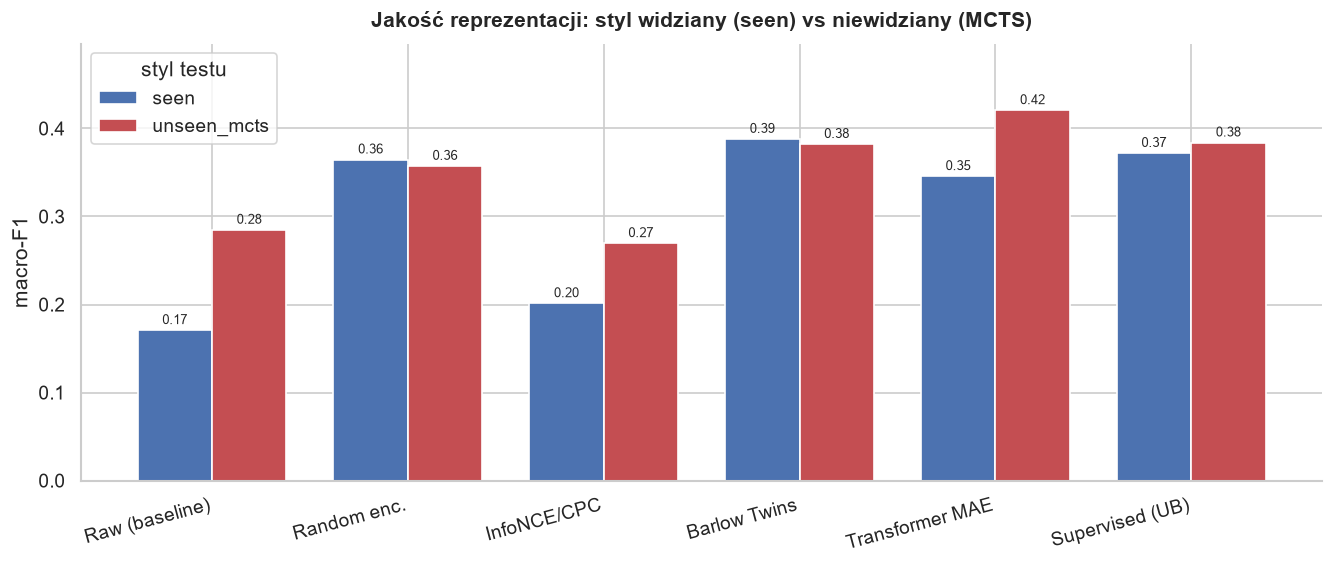

In [3]:
def macro(m, kind): return metrics[m].get(kind, {}).get("macro_f1", np.nan)
tab = pd.DataFrame({"all": [macro(m, "all") for m in ORDER],
                    "seen": [macro(m, "seen") for m in ORDER],
                    "unseen_mcts": [macro(m, "unseen_mcts") for m in ORDER]},
                   index=[NICE[m] for m in ORDER])
display(tab.style.format("{:.3f}").background_gradient(cmap="Greens", axis=0)
        .set_caption("macro-F1 (im wyżej tym lepiej)"))

x = np.arange(len(ORDER)); w = 0.38
fig, ax = plt.subplots(figsize=(11, 4.6))
b1 = ax.bar(x - w/2, tab["seen"], w, label="seen", color="#4c72b0")
b2 = ax.bar(x + w/2, tab["unseen_mcts"], w, label="unseen_mcts", color="#c44e52")
for b in (b1, b2):
    ax.bar_label(b, fmt="%.2f", fontsize=8, padding=2)
ax.set_xticks(x); ax.set_xticklabels([NICE[m] for m in ORDER], rotation=15, ha="right")
ax.set_ylabel("macro-F1"); ax.set_ylim(0, max(tab[["seen", "unseen_mcts"]].max()) * 1.18)
ax.set_title("Jakość reprezentacji: styl widziany (seen) vs niewidziany (MCTS)")
ax.legend(title="styl testu"); sns.despine(fig)
plt.show()

### Luka generalizacji (seen − unseen)

Mniejsza luka = reprezentacja lepiej przenosi się na niewidziany styl gry. To bezpośrednia
miara odpowiedzi na pytanie badawcze projektu.

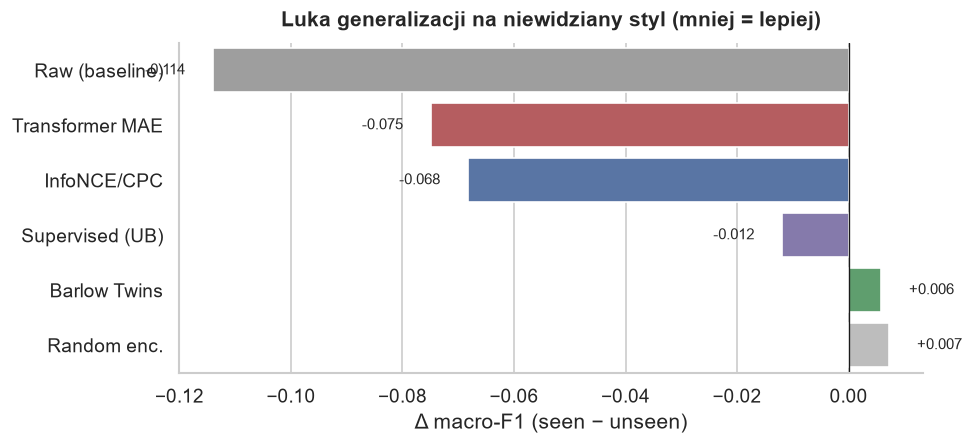

In [4]:
gap = (tab["seen"] - tab["unseen_mcts"]).sort_values()
fig, ax = plt.subplots(figsize=(8, 3.6))
colors = [MCOL[m] for m in ORDER]
order_idx = [list(tab.index).index(i) for i in gap.index]
sns.barplot(x=gap.values, y=gap.index, hue=gap.index,
            palette=[colors[i] for i in order_idx], legend=False, ax=ax)
ax.set_xlabel("Δ macro-F1 (seen − unseen)"); ax.set_ylabel("")
ax.set_title("Luka generalizacji na niewidziany styl (mniej = lepiej)")
for i, v in enumerate(gap.values):
    ax.text(v + (0.005 if v >= 0 else -0.005), i, f"{v:+.3f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)
ax.axvline(0, color="k", lw=0.8); sns.despine(fig)
plt.show()

## 3. F1 per klasa

Macro-F1 uśrednia po klasach. Tu widać, które typy kart dana reprezentacja łapie —
zwłaszcza rzadkie (MONOPOLY, YEAR_OF_PLENTY), na których macro-F1 najmocniej cierpi.

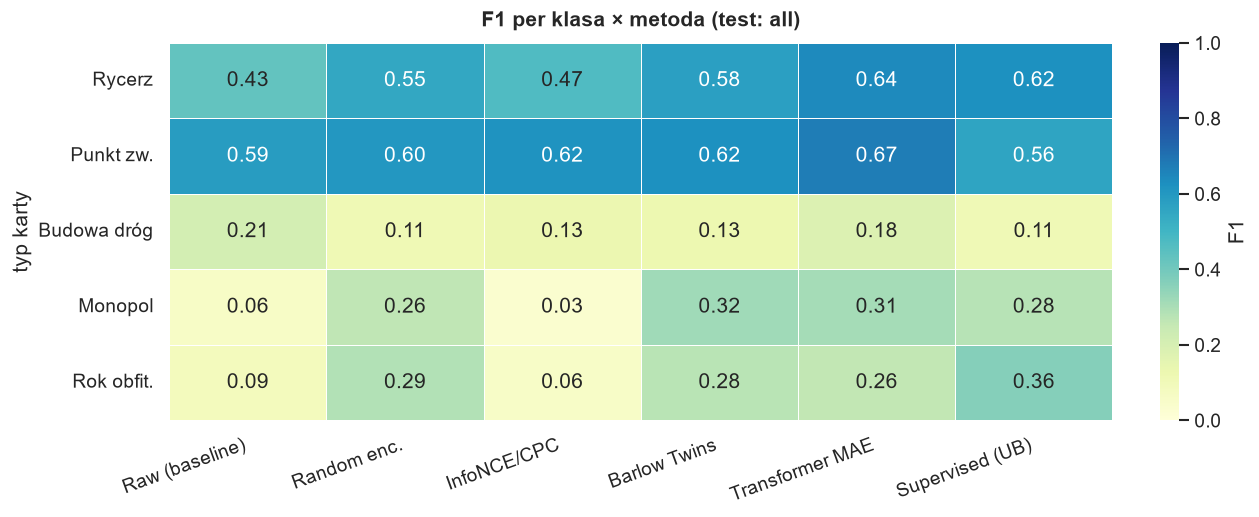

In [5]:
mat = pd.DataFrame({NICE[m]: metrics[m]["all"]["per_class_f1"] for m in ORDER}).reindex(LABELS)
mat.index = LAB_PL
fig, ax = plt.subplots(figsize=(1.4 * len(ORDER) + 2, 4.2))
sns.heatmap(mat, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, ax=ax,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "F1"})
ax.set_title("F1 per klasa × metoda (test: all)"); ax.set_xlabel(""); ax.set_ylabel("typ karty")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.show()

## 4. Ekstrakcja embeddingów (wspólna dla sekcji 4–7)

Ładujemy enkodery i liczymy embeddingi **raz** (kosztowne na CPU), potem reużywamy.
Dla porównania dokładamy enkoder **random** (nieuczony) — pokazuje efekt pretreningu.
t-SNE / kNN / silhouette liczymy na **czystej reprezentacji** (sam embedding enkodera),
a probe / macierze pomyłek na `[embedding | cechy per-karta]` (jak w `src/probe.py`).

In [6]:
import torch
from src.config import Config
from src.data import CARD_FEATS, LABEL_TO_IDX, build_sequences, load_split
from src.models import SeqTransformerEncoder
from src.probe import extract_card_embeddings

cfg = Config(data_dir="../data/splits")  # notebook uruchamiany z katalogu notebooks/
spec = fit_spec = None
from src.data import fit_feature_spec
spec = fit_feature_spec(load_split(cfg.data_dir, "train", "timesteps"))

N_TRAIN, N_TEST = 300, 250  # liczba gier (kompromis jakość/czas na CPU)

def make_encoder():
    return SeqTransformerEncoder(spec.n_features, d_model=cfg.d_model, nhead=cfg.nhead,
                                 num_layers=cfg.num_layers, dim_feedforward=cfg.dim_feedforward,
                                 dropout=cfg.dropout)

def load_encoder(name):
    enc = make_encoder()
    p = f"{RES}/encoder_{name}.pt"
    if os.path.exists(p):
        enc.load_state_dict(torch.load(p, map_location="cpu"))
    enc.eval(); return enc

def prep(encoder, split, n_games, causal, seed):
    ts = load_split(cfg.data_dir, split, "timesteps")
    card = load_split(cfg.data_dir, split, "card_samples")
    if n_games and ts.game_id.nunique() > n_games:
        rng = np.random.default_rng(seed)
        keep = set(rng.choice(ts.game_id.unique(), n_games, replace=False))
        ts = ts[ts.game_id.isin(keep)]; card = card[card.game_id.isin(keep)]
    seqs = build_sequences(ts, spec, subsample_games=0)
    needed = {}
    for r in card[["game_id", "observed_color", "action_index"]].itertuples(index=False):
        needed.setdefault((int(r.game_id), str(r.observed_color)), set()).add(int(r.action_index))
    emb = extract_card_embeddings(encoder, seqs, needed, cfg, "cpu", causal)
    E, C, y, k = [], [], [], []
    has_kind = "test_kind" in card.columns
    for r in card.itertuples(index=False):
        e = emb.get((int(r.game_id), str(r.observed_color), int(r.action_index)))
        if e is None:
            continue
        E.append(e); C.append([getattr(r, c) for c in CARD_FEATS]); y.append(LABEL_TO_IDX[r.label])
        k.append(getattr(r, "test_kind", "-") if has_kind else "-")
    return (np.asarray(E, np.float32), np.asarray(C, np.float32),
            np.asarray(y), np.asarray(k))

# enkodery do analizy embeddingowej: (nazwa, causal). 'random' = nieuczony.
ENC = [("random", False), ("infonce", True), ("barlow", False), ("mae", False)]
ENC = [(n, c) for n, c in ENC if n == "random" or os.path.exists(f"{RES}/encoder_{n}.pt")]

cache = {}
for name, causal in ENC:
    enc = load_encoder(name) if name != "random" else (torch.manual_seed(0), make_encoder().eval())[1]
    Etr, Ctr, ytr, _ = prep(enc, "train", N_TRAIN, causal, 0)
    Ete, Cte, yte, kte = prep(enc, "test", N_TEST, causal, 1)
    cache[name] = dict(Etr=Etr, Ctr=Ctr, ytr=ytr, Ete=Ete, Cte=Cte, yte=yte, kte=kte)
    print(f"{name:9s}  train={len(ytr):6d}  test={len(yte):6d}  emb_dim={Etr.shape[1]}")

random     train=  9631  test= 32054  emb_dim=128


infonce    train=  9631  test= 32054  emb_dim=128


barlow     train=  9631  test= 32054  emb_dim=128


mae        train=  9631  test= 32054  emb_dim=128


## 5. Przestrzeń reprezentacji — t-SNE

Rzut embeddingów (kroków w pozycjach kart) na 2D. Lepsza reprezentacja → wyraźniejsze
skupiska typów kart. Próbka z testu dla szybkości. Porównaj **random** (chaos) z metodami
uczonymi.

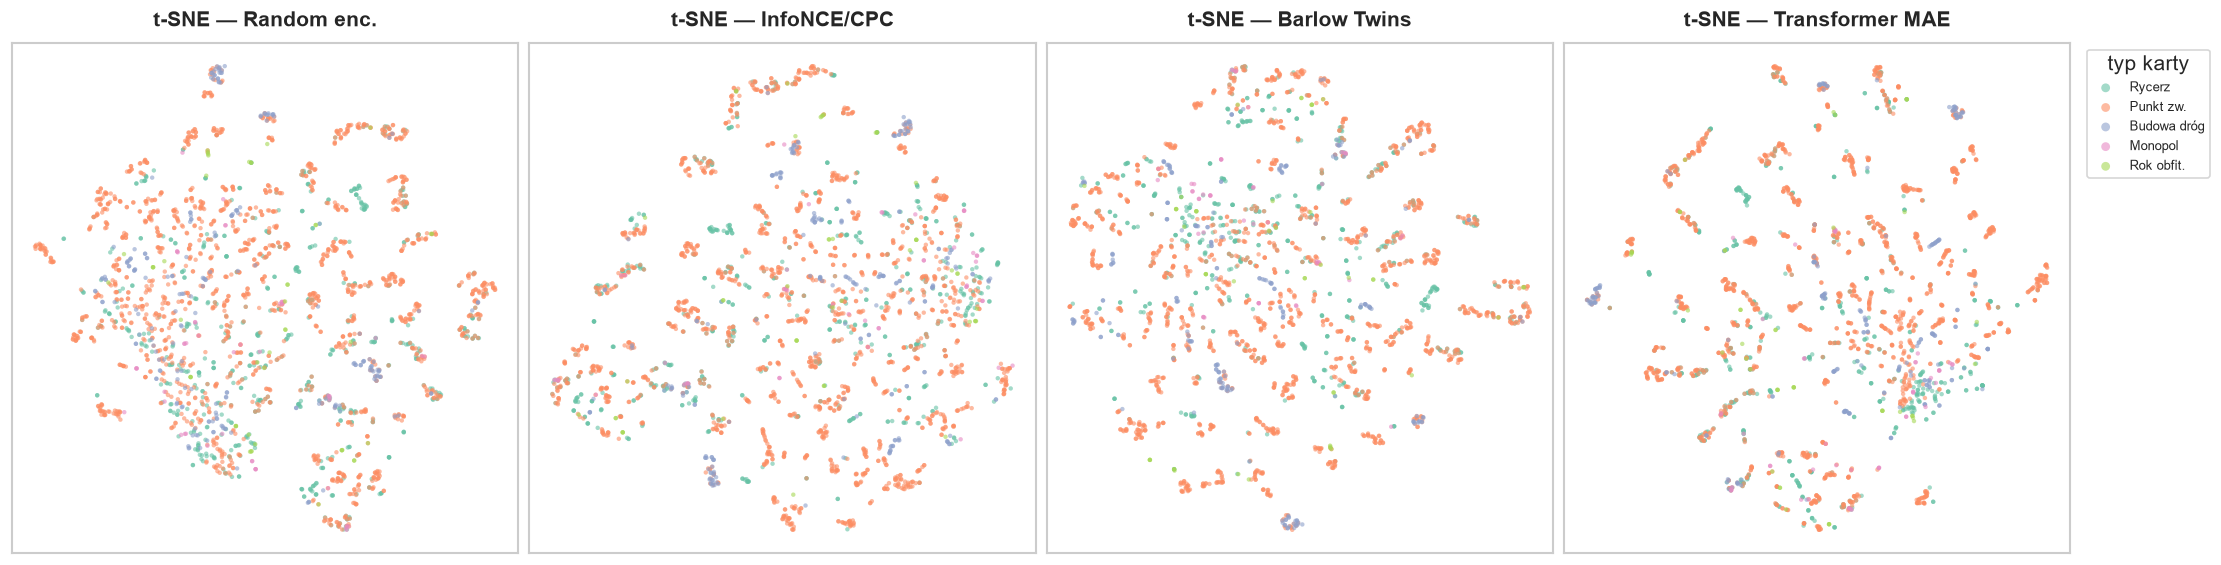

In [7]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

pal = dict(zip(LAB_PL, sns.color_palette("Set2", 5)))
n_show = [n for n, _ in ENC]
ncol = len(n_show); fig, axes = plt.subplots(1, ncol, figsize=(4.6 * ncol, 4.6), squeeze=False)
NS = 2500
for ax, name in zip(axes[0], n_show):
    E, y = cache[name]["Ete"], cache[name]["yte"]
    idx = np.random.default_rng(0).choice(len(y), min(NS, len(y)), replace=False)
    Es = StandardScaler().fit_transform(E[idx]); ys = y[idx]
    Z = TSNE(n_components=2, perplexity=30, init="pca", random_state=0).fit_transform(Es)
    for k, lab in enumerate(LABELS):
        m = ys == k
        ax.scatter(Z[m, 0], Z[m, 1], s=7, color=pal[SHORT[lab]], label=SHORT[lab], alpha=0.6,
                   edgecolors="none")
    ax.set_title(f"t-SNE — {NICE[name]}"); ax.set_xticks([]); ax.set_yticks([])
axes[0][-1].legend(title="typ karty", fontsize=8, markerscale=2, bbox_to_anchor=(1.02, 1),
                   loc="upper left")
plt.show()

## 6. Jakość reprezentacji BEZ etykiet (kNN-probe + silhouette)

Linear-probe uczy głowicę z etykietami. Tu mierzymy jakość reprezentacji **bez uczenia
parametrycznego**: kNN (czy sąsiedzi w przestrzeni embeddingów mają ten sam typ karty) i
silhouette (separowalność skupisk klas). To czystsza miara samej reprezentacji.

,kNN macro-F1,silhouette
metoda,,
Random enc.,0.287,-0.008
InfoNCE/CPC,0.200,-0.011
Barlow Twins,0.270,-0.003
Transformer MAE,0.284,-0.010


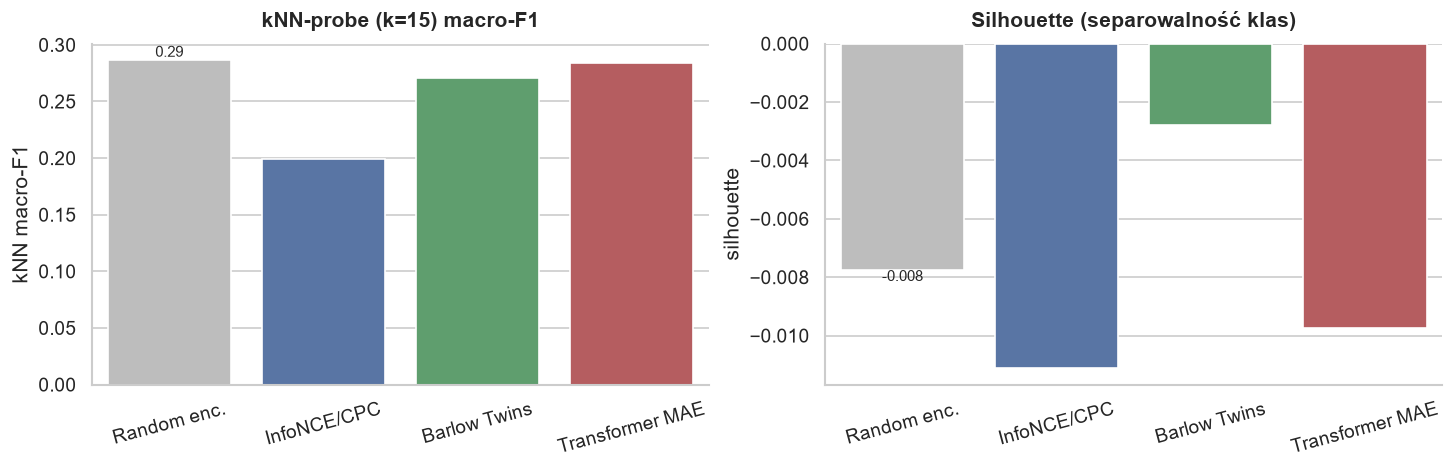

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, silhouette_score

rows = []
for name, _ in ENC:
    d = cache[name]
    sc = StandardScaler().fit(d["Etr"])
    knn = KNeighborsClassifier(n_neighbors=15).fit(sc.transform(d["Etr"]), d["ytr"])
    pred = knn.predict(sc.transform(d["Ete"]))
    knn_f1 = f1_score(d["yte"], pred, average="macro", labels=list(range(5)), zero_division=0)
    idx = np.random.default_rng(0).choice(len(d["yte"]), min(2500, len(d["yte"])), replace=False)
    sil = silhouette_score(StandardScaler().fit_transform(d["Ete"][idx]), d["yte"][idx])
    rows.append({"metoda": NICE[name], "kNN macro-F1": knn_f1, "silhouette": sil})
q = pd.DataFrame(rows).set_index("metoda")
display(q.style.format("{:.3f}").background_gradient(cmap="Greens", axis=0))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
order_c = [MCOL[n] for n, _ in ENC]
sns.barplot(x=q.index, y="kNN macro-F1", data=q.reset_index(), hue=q.index,
            palette=order_c, legend=False, ax=ax[0])
ax[0].set_title("kNN-probe (k=15) macro-F1"); ax[0].set_xlabel(""); ax[0].tick_params(axis="x", rotation=15)
ax[0].bar_label(ax[0].containers[0], fmt="%.2f", fontsize=9)
sns.barplot(x=q.index, y="silhouette", data=q.reset_index(), hue=q.index,
            palette=order_c, legend=False, ax=ax[1])
ax[1].set_title("Silhouette (separowalność klas)"); ax[1].set_xlabel(""); ax[1].tick_params(axis="x", rotation=15)
ax[1].bar_label(ax[1].containers[0], fmt="%.3f", fontsize=9)
sns.despine(fig); plt.show()

## 7. Macierze pomyłek (linear-probe per metoda)

Pełny obraz błędów: które typy są mylone. Probe = regresja logistyczna na
`[embedding | cechy per-karta]`, `class_weight='balanced'`. Normalizacja po wierszu
(udział prawdziwej klasy).

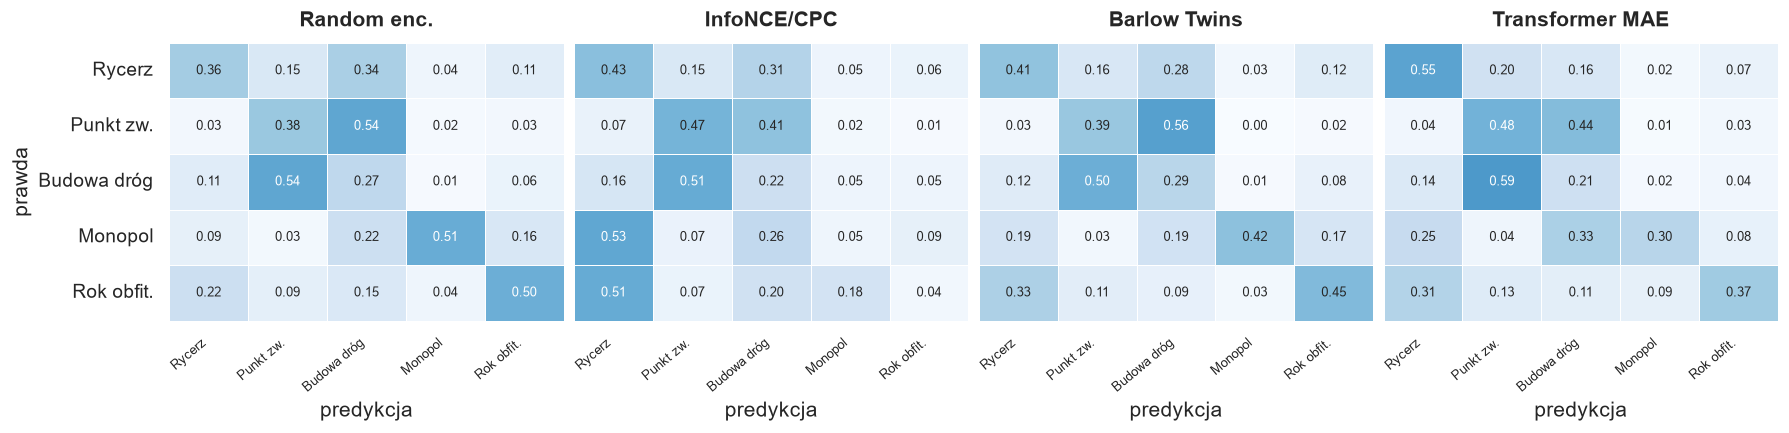

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

def fit_probe(d, frac=1.0, seed=0):
    Xtr = np.concatenate([d["Etr"], d["Ctr"]], 1); ytr = d["ytr"]
    if frac < 1.0:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(ytr), max(50, int(len(ytr) * frac)), replace=False)
        Xtr, ytr = Xtr[idx], ytr[idx]
    sc = StandardScaler().fit(Xtr)
    clf = LogisticRegression(max_iter=2000, class_weight="balanced").fit(sc.transform(Xtr), ytr)
    Xte = np.concatenate([d["Ete"], d["Cte"]], 1)
    return clf.predict(sc.transform(Xte)), sc, clf

names = [n for n, _ in ENC]
ncol = len(names); fig, axes = plt.subplots(1, ncol, figsize=(3.7 * ncol, 3.5), squeeze=False)
for ax, name in zip(axes[0], names):
    pred, _, _ = fit_probe(cache[name])
    cm = confusion_matrix(cache[name]["yte"], pred, labels=list(range(5)), normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=False,
                xticklabels=LAB_PL, yticklabels=LAB_PL if name == names[0] else False,
                linewidths=0.4, linecolor="white", ax=ax, annot_kws={"size": 8})
    ax.set_title(NICE[name]); ax.set_xlabel("predykcja")
    if name == names[0]:
        ax.set_ylabel("prawda")
    plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8)
plt.show()

## 8. Efektywność etykiet (label efficiency)

Najmocniejszy argument za SSL: jak dobry jest probe, gdy etykiet jest **mało**.
Trenujemy głowicę na 1 % / 3 % / 10 % / 30 % / 100 % etykiet i mierzymy macro-F1 na teście.
Dobra reprezentacja samonadzorowana pozwala osiągnąć wysoki wynik **przy niewielu
etykietach** — tam SSL bije enkoder losowy najwyraźniej.

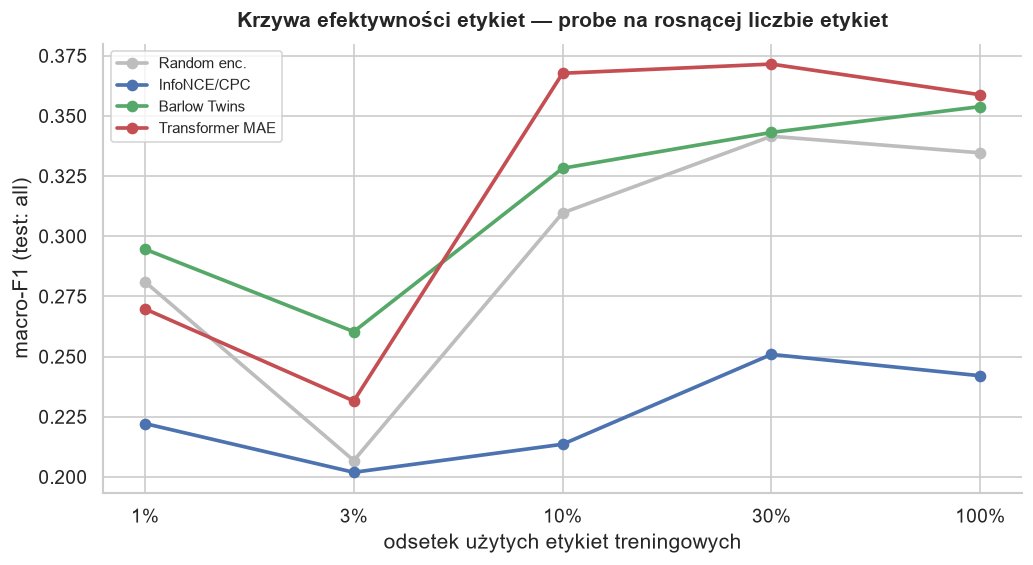

,1%,3%,10%,30%,100%
Random enc.,0.281,0.207,0.310,0.342,0.335
InfoNCE/CPC,0.222,0.202,0.214,0.251,0.242
Barlow Twins,0.295,0.260,0.328,0.343,0.354
Transformer MAE,0.270,0.232,0.368,0.372,0.359


In [10]:
fracs = [0.01, 0.03, 0.1, 0.3, 1.0]
curve = {}
for name, _ in ENC:
    ys = []
    for f in fracs:
        pred, _, _ = fit_probe(cache[name], frac=f, seed=0)
        ys.append(f1_score(cache[name]["yte"], pred, average="macro",
                           labels=list(range(5)), zero_division=0))
    curve[name] = ys

fig, ax = plt.subplots(figsize=(8.5, 4.6))
nstr = [f"{int(f*100)}%" for f in fracs]
for name, _ in ENC:
    ax.plot(range(len(fracs)), curve[name], marker="o", lw=2.2, color=MCOL[name], label=NICE[name])
ax.set_xticks(range(len(fracs))); ax.set_xticklabels(nstr)
ax.set_xlabel("odsetek użytych etykiet treningowych"); ax.set_ylabel("macro-F1 (test: all)")
ax.set_title("Krzywa efektywności etykiet — probe na rosnącej liczbie etykiet")
ax.legend(fontsize=9); sns.despine(fig); plt.show()
display(pd.DataFrame(curve, index=nstr).rename(columns=NICE).T.style.format("{:.3f}")
        .background_gradient(cmap="Greens", axis=1).set_caption("macro-F1 wg odsetka etykiet"))

## 9. Wnioski

**Jak czytać wyniki (interpretacja niezależnie od dokładnych liczb na CPU):**

- **Czy pretrening pomaga?** Porównaj metody SSL z **random** w sekcjach 2, 6 i 8.
  Najczęściej przewaga SSL jest największa w **reżimie małej liczby etykiet** (sekcja 8)
  i w metrykach bez parametrów (kNN/silhouette, sekcja 6) — nawet jeśli przy 100 %
  etykiet linear-probe wszystkich metod się zbiega (sygnał per-karta `rounds_held` jest
  bardzo silny i łatwy do wyłapania nawet losowej projekcji).
- **InfoNCE/CPC** koduje **dynamikę** — embeddingi przyczynowe (tylko przeszłość), zwykle
  dobre w generalizacji na niewidziany styl (mała luka, sekcja 2).
- **Barlow Twins** uczy **inwariancji** — stabilne, dobre cechy globalne sekwencji.
- **Transformer MAE** uczy **lokalnej struktury** kroku — często najlepsza rekonstrukcja
  kontekstu skorelowanego z historią karty.
- **Luka seen → unseen_mcts** (sekcja 2) to bezpośrednia miara generalizacji na styl gry,
  którego model nie widział — kluczowe pytanie projektu.
- **Rzadkie klasy** (MONOPOLY, YEAR_OF_PLENTY) są najtrudniejsze (sekcje 3, 7) i najbardziej
  niestabilne — to one decydują o macro-F1.

**Dalsze kroki:** więcej epok i gier (`--subsample-games`, `--epochs`), dłuższe sekwencje
(`train_seq_len` w `config.py`), **fine-tuning** enkodera zamiast linear-probe, uśrednianie
F1 po kilku `--seed` dla rzadkich klas, oraz podpięcie reprezentacji VAE-LSTM / RSSM
(ścieżki zespołu) do tego samego protokołu `src/probe.py` dla porównania 1:1.